# 1 Import necessary libraries

In [11]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 1.7 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.7 MB/s  0:00:00



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score

# 2 import dataset

In [46]:
credit_card_data =pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


# 3 data understanding

In [8]:
credit_card_data.shape

(30000, 25)

In [9]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX              str
EDUCATION        str
MARRIAGE         str
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [10]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

# 4 data preprocessing

## 4.1 data cleaning - already cleaned data

## 4.2 data transformation - encoding \ scaling \ train_test_split

### 4.2.1 ENCODING

In [47]:
le = LabelEncoder()
credit_card_data["SEX"] = le.fit_transform(credit_card_data["SEX"])
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data["MARRIAGE"])
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,0,3,0,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,0,3,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,0,3,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,0,3,0,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,3,0,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,1,0,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,1,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,3,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,1,0,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [17]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [18]:
credit_card_data.nunique()

ID           30000
LIMIT_BAL       81
SEX              2
EDUCATION        4
MARRIAGE         3
AGE             56
PAY_1           11
PAY_2           11
PAY_3           11
PAY_4           11
PAY_5           10
PAY_6           10
BILL_AMT1    22723
BILL_AMT2    22346
BILL_AMT3    22026
BILL_AMT4    21548
BILL_AMT5    21010
BILL_AMT6    20604
PAY_AMT1      7943
PAY_AMT2      7899
PAY_AMT3      7518
PAY_AMT4      6937
PAY_AMT5      6897
PAY_AMT6      6939
DEFAULT          2
dtype: int64

In [48]:
#credit_card_data.drop(labels = "ID", axis = 1,inplace = True)
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,0,3,0,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,0,3,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,0,3,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,0,3,0,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,3,0,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,1,0,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,1,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,3,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,1,0,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


### X and y seperation 

In [49]:
y = credit_card_data["DEFAULT"]

In [50]:
# 14 continuous columns
X_continuous = pd.DataFrame(data = {"LIMIT_BAL" : credit_card_data["LIMIT_BAL"], 
                                    "AGE" : credit_card_data["AGE"], 
                                    "BILL_AMT1" : credit_card_data["BILL_AMT1"], 
                                    "BILL_AMT2" : credit_card_data["BILL_AMT2"], 
                                    "BILL_AMT3" : credit_card_data["BILL_AMT3"], 
                                   "BILL_AMT4" : credit_card_data["BILL_AMT4"],
                                   "BILL_AMT5" : credit_card_data["BILL_AMT5"],
                                   "BILL_AMT6" : credit_card_data["BILL_AMT6"],
                                   "PAY_AMT1" : credit_card_data["PAY_AMT1"],
                                   "PAY_AMT2" : credit_card_data["PAY_AMT2"],
                                   "PAY_AMT3" : credit_card_data["PAY_AMT3"],
                                    "PAY_AMT4" : credit_card_data["PAY_AMT4"],
                                    "PAY_AMT5" : credit_card_data["PAY_AMT5"],
                                    "PAY_AMT6" : credit_card_data["PAY_AMT6"]
                                   })
X_continuous

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,24,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,34,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,37,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,57,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,39,188948.0,192815.0,208365.0,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0
29996,150000.0,43,1683.0,1828.0,3502.0,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0
29997,30000.0,37,3565.0,3356.0,2758.0,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0
29998,80000.0,41,-1645.0,78379.0,76304.0,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0


In [51]:
X_discrete = pd.DataFrame(data = {"ID" : credit_card_data["ID"],
                                    "SEX" : credit_card_data["SEX"], 
                                    "EDUCATION" : credit_card_data["EDUCATION"], 
                                    "MARRIAGE" : credit_card_data["MARRIAGE"], 
                                    "PAY_1" : credit_card_data["PAY_1"],
                                   "PAY_2" : credit_card_data["PAY_2"],
                                   "PAY_3" : credit_card_data["PAY_3"],
                                    "PAY_4" : credit_card_data["PAY_4"],
                                    "PAY_5" : credit_card_data["PAY_5"],
                                    "PAY_6" : credit_card_data["PAY_6"]
                                   })
X_discrete

,ID,SEX,EDUCATION,MARRIAGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,1,0,3,0,2,2,-1,-1,-2,-2
1,2,0,3,2,-1,2,0,0,0,2
2,3,0,3,2,0,0,0,0,0,0
3,4,0,3,0,0,0,0,0,0,0
4,5,1,3,0,-1,0,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
29995,29996,1,1,0,0,0,0,0,0,0
29996,29997,1,1,2,-1,-1,-1,-1,0,0
29997,29998,1,3,2,4,3,2,-1,0,0
29998,29999,1,1,0,1,-1,0,0,0,-1


### 4.2.2 TRAIN TEST SPLIT

In [52]:
X_cont_train, X_cont_test, X_disc_train, X_disc_test, y_train, y_test = train_test_split(X_continuous,X_discrete,y,test_size = 0.20, random_state = 123, shuffle=True,
    stratify=y)

In [55]:
X_cont_train.shape,y_train.shape,X_disc_train.shape

((24000, 14), (24000,), (24000, 10))

In [56]:
X_cont_test.shape,X_disc_test.shape,y_test.shape

((6000, 14), (6000, 10), (6000,))

### 4.2.3 now scale the data - fit transform for train data, only transform for test data

In [57]:
scaler = StandardScaler()

In [58]:
scaled_X_cont_train = pd.DataFrame(scaler.fit_transform(X_cont_train),columns = X_continuous.columns)
scaled_X_cont_train


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,-0.673150,1.571818,-0.660558,-0.657021,-0.644961,-0.607386,-0.598947,-0.596988,-0.347657,-0.245765,-0.179937,-0.300766,-0.248963,1.022263
1,2.556474,0.813600,0.992458,1.090026,1.185027,1.335170,1.307092,0.984805,-0.065849,-0.047903,-0.028960,-0.037996,-0.095473,-0.104010
2,-0.826942,-0.486203,-0.647978,-0.680159,-0.676742,-0.666707,-0.658525,-0.539446,-0.292122,-0.245765,-0.273528,-0.301013,0.121584,-0.293680
3,0.864766,-0.161252,-0.696504,-0.212231,-0.206659,1.355846,-0.598360,-0.651014,1.760379,-0.245765,6.928709,-0.056906,-0.322225,-0.252849
4,1.787516,-0.594520,-0.657460,-0.654689,-0.632005,-0.336638,-0.413932,-0.384352,-0.183027,-0.112589,0.906946,-0.270114,-0.253947,-0.266592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,-0.903838,-1.027787,-0.103063,-0.101290,-0.069584,-0.087401,-0.079751,-0.090577,-0.210178,-0.142432,-0.198699,-0.210972,-0.233464,-0.217264
23996,-0.750046,1.246867,-0.318714,-0.283738,-0.181090,-0.151562,-0.089406,-0.028269,-0.224247,0.002234,-0.290034,-0.177415,-0.132139,-0.293680
23997,2.556474,0.705283,-0.283502,-0.666265,-0.666201,-0.663567,-0.615697,-0.586856,-0.233873,-0.204432,-0.290034,-0.115616,-0.049112,0.048479
23998,-0.903838,-0.594520,-0.251685,-0.246804,-0.292525,-0.380046,-0.355675,-0.328426,-0.255778,-0.190957,-0.254711,-0.177415,-0.265964,-0.236653


In [59]:
scaled_X_cont_test = pd.DataFrame(scaler.transform(X_cont_test),columns = X_continuous.columns)
scaled_X_cont_test

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,0.095808,-0.811154,-0.645736,-0.613921,-0.610434,-0.539405,-0.535846,-0.444410,-0.223938,-0.244484,-0.014929,-0.239214,0.019166,-0.008547
1,-0.519359,-0.702837,-0.691722,-0.686692,-0.672730,-0.661000,-0.662782,-0.641032,-0.323592,-0.229645,-0.247118,-0.301013,-0.281327,-0.293680
2,-1.057630,1.246867,-0.315644,-0.291577,-0.287908,-0.238517,-0.204421,-0.181397,-0.236588,-0.245765,-0.163486,-0.226854,-0.233464,-0.293680
3,-1.057630,1.463501,-0.318837,-0.260670,-0.256674,-0.239832,-0.196168,-0.169682,-0.142179,-0.245765,-0.226870,-0.227163,-0.260092,-0.236653
4,-0.134880,-0.594520,0.194044,-0.692171,-0.678339,-0.673062,-0.662782,-0.651014,-0.347657,-0.245765,-0.290034,-0.301013,-0.322225,-0.293680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,-0.288671,0.272015,-0.610619,-0.616660,-0.599591,-0.565880,0.958640,1.010451,-0.280522,-0.196620,-0.144449,6.162574,-0.092947,-0.104694
5996,0.249599,0.705283,-0.685364,-0.672419,-0.625519,-0.673062,-0.660336,-0.640865,-0.260899,-0.093948,-0.290034,-0.291744,-0.280644,-0.240132
5997,-0.903838,-1.136104,-0.123210,-0.084445,-0.170607,-0.315900,-0.353392,-0.325827,-0.236156,-0.187692,-0.214875,-0.239214,-0.253947,-0.236653
5998,-0.596255,0.272015,0.511203,0.542218,0.577696,0.715410,0.443049,0.504223,-0.156186,-0.101099,-0.058946,-0.151088,-0.143814,-0.122600


In [60]:
X_train = pd.concat(
    [scaled_X_cont_train.reset_index(drop=True), X_disc_train.reset_index(drop=True)],
    axis=1
)
X_train

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,ID,SEX,EDUCATION,MARRIAGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,-0.673150,1.571818,-0.660558,-0.657021,-0.644961,-0.607386,-0.598947,-0.596988,-0.347657,-0.245765,...,23834,0,1,0,2,3,2,2,2,0
1,2.556474,0.813600,0.992458,1.090026,1.185027,1.335170,1.307092,0.984805,-0.065849,-0.047903,...,27013,1,0,0,0,0,0,0,0,0
2,-0.826942,-0.486203,-0.647978,-0.680159,-0.676742,-0.666707,-0.658525,-0.539446,-0.292122,-0.245765,...,12497,0,0,2,0,-1,2,2,2,2
3,0.864766,-0.161252,-0.696504,-0.212231,-0.206659,1.355846,-0.598360,-0.651014,1.760379,-0.245765,...,25520,0,3,2,-1,-1,2,-1,-1,-1
4,1.787516,-0.594520,-0.657460,-0.654689,-0.632005,-0.336638,-0.413932,-0.384352,-0.183027,-0.112589,...,18881,0,0,2,-2,-2,-1,-1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,-0.903838,-1.027787,-0.103063,-0.101290,-0.069584,-0.087401,-0.079751,-0.090577,-0.210178,-0.142432,...,3229,0,3,0,0,0,0,0,0,0
23996,-0.750046,1.246867,-0.318714,-0.283738,-0.181090,-0.151562,-0.089406,-0.028269,-0.224247,0.002234,...,18274,1,3,1,0,0,0,2,0,0
23997,2.556474,0.705283,-0.283502,-0.666265,-0.666201,-0.663567,-0.615697,-0.586856,-0.233873,-0.204432,...,1549,0,0,2,-1,-1,-1,2,-1,-1
23998,-0.903838,-0.594520,-0.251685,-0.246804,-0.292525,-0.380046,-0.355675,-0.328426,-0.255778,-0.190957,...,7577,1,3,2,0,0,0,0,0,0


In [61]:
X_train.isna().sum()

LIMIT_BAL    0
AGE          0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
ID           0
SEX          0
EDUCATION    0
MARRIAGE     0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
dtype: int64

In [62]:
X_test = pd.concat(
    [scaled_X_cont_test.reset_index(drop=True), X_disc_test.reset_index(drop=True)],
    axis=1
)
X_test

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,ID,SEX,EDUCATION,MARRIAGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,0.095808,-0.811154,-0.645736,-0.613921,-0.610434,-0.539405,-0.535846,-0.444410,-0.223938,-0.244484,...,12983,0,0,2,1,2,2,0,0,0
1,-0.519359,-0.702837,-0.691722,-0.686692,-0.672730,-0.661000,-0.662782,-0.641032,-0.323592,-0.229645,...,29445,1,0,2,-2,-2,-2,-2,-2,-2
2,-1.057630,1.246867,-0.315644,-0.291577,-0.287908,-0.238517,-0.204421,-0.181397,-0.236588,-0.245765,...,12393,0,1,0,2,2,2,2,2,2
3,-1.057630,1.463501,-0.318837,-0.260670,-0.256674,-0.239832,-0.196168,-0.169682,-0.142179,-0.245765,...,5592,0,1,2,0,0,2,0,0,0
4,-0.134880,-0.594520,0.194044,-0.692171,-0.678339,-0.673062,-0.662782,-0.651014,-0.347657,-0.245765,...,7283,0,3,2,0,0,-2,-2,-2,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,-0.288671,0.272015,-0.610619,-0.616660,-0.599591,-0.565880,0.958640,1.010451,-0.280522,-0.196620,...,26863,1,1,0,0,0,0,0,-1,0
5996,0.249599,0.705283,-0.685364,-0.672419,-0.625519,-0.673062,-0.660336,-0.640865,-0.260899,-0.093948,...,28887,0,1,0,-1,-1,-1,-1,-1,-1
5997,-0.903838,-1.136104,-0.123210,-0.084445,-0.170607,-0.315900,-0.353392,-0.325827,-0.236156,-0.187692,...,17825,1,3,0,0,0,0,0,0,0
5998,-0.596255,0.272015,0.511203,0.542218,0.577696,0.715410,0.443049,0.504223,-0.156186,-0.101099,...,24698,1,0,0,2,0,0,0,0,0


In [64]:
X_test.isna().sum()

LIMIT_BAL    0
AGE          0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
ID           0
SEX          0
EDUCATION    0
MARRIAGE     0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
dtype: int64

# 5.MODEL BUILDING

In [65]:
ada_classifier = AdaBoostClassifier()
gb_classifier = GradientBoostingClassifier(n_estimators=50)
xgb_classifier = XGBClassifier(n_estimators=50)
lgb_classifier = LGBMClassifier(n_estimators=50)

In [66]:
%%time
ada_classifier.fit(X_train,y_train)

CPU times: total: 2.27 s
Wall time: 2.32 s


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.18,0.41,0.44,...,0.5 ,0.5 ,0.5 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.51,0.36,0.26,...,0.01,0.01,0.01]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1934249895), DecisionTreeC...te=1468378558), DecisionTreeC...ate=924912067), DecisionTreeC...te=1003809193), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](24,)","[0.06,0. ,0.01,...,0. ,0.02,0.04]"


In [67]:
%%time
gb_classifier.fit(X_train,y_train)

CPU times: total: 5.38 s
Wall time: 5.53 s


,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to com

In [68]:
%%time
xgb_classifier.fit(X_train,y_train)

CPU times: total: 1.5 s
Wall time: 333 ms


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
%%time
lgb_classifier.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003995 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3514
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 875 ms
Wall time: 223 ms


,n_estimators,50
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [76]:
y_train_pred_ada = ada_classifier.predict(X_train)
y_test_pred_ada = ada_classifier.predict(X_test)
y_train_pred_gb = gb_classifier.predict(X_train)
y_test_pred_gb = gb_classifier.predict(X_test)
y_train_pred_xgb = xgb_classifier.predict(X_train)
y_test_pred_xgb = xgb_classifier.predict(X_test)
y_train_pred_lgb = lgb_classifier.predict(X_train)
y_test_pred_lgb = lgb_classifier.predict(X_test)

In [77]:
print("Accuracy score - ADA train data :", round(accuracy_score(y_train,y_train_pred_ada),4))
print("Accuracy score - GB train data :", round(accuracy_score(y_train,y_train_pred_gb),4))
print("Accuracy score - XGB train data :", round(accuracy_score(y_train,y_train_pred_xgb),4))
print("Accuracy score - LGB train data :", round(accuracy_score(y_train,y_train_pred_lgb),4))

Accuracy score - ADA train data : 0.8186
Accuracy score - GB train data : 0.8245
Accuracy score - XGB train data : 0.8652
Accuracy score - LGB train data : 0.8321


# feature importance

In [82]:
ada_imp = ada_classifier.feature_importances_
gb_imp = gb_classifier.feature_importances_
xgb_imp = xgb_classifier.feature_importances_
lgb_imp = lgb_classifier.feature_importances_
ada_classifier.feature_names_in_

In [89]:
feature_imp = pd.DataFrame({"Feature names" : ada_classifier.feature_names_in_,
                            "ADA_FEATURE_IMPORTANCE" : ada_imp , 
              "GB_FEATURE_IMPORTANCE" : gb_imp,
              "XGB_FEATURE_IMPORTANCE" : xgb_imp,
             "LGB_FEATURE_IMPORTANCE" : lgb_imp})
feature_imp

,Feature names,ADA_FEATURE_IMPORTANCE,GB_FEATURE_IMPORTANCE,XGB_FEATURE_IMPORTANCE,LGB_FEATURE_IMPORTANCE
0,LIMIT_BAL,0.057269,0.025037,0.020258,117
1,AGE,0.000000,0.002902,0.014866,95
2,BILL_AMT1,0.014796,0.021755,0.020940,132
3,BILL_AMT2,0.015358,0.004696,0.017479,61
4,BILL_AMT3,0.000000,0.003079,0.014829,65
5,BILL_AMT4,0.000000,0.003510,0.017034,56
6,BILL_AMT5,0.018466,0.000336,0.014901,52
7,BILL_AMT6,0.000000,0.002730,0.013782,47
8,PAY_AMT1,0.087824,0.020567,0.020370,68
9,PAY_AMT2,0.064727,0.018342,0.019742,93


In [85]:
import seaborn as sns

<Axes: xlabel='ADA_FEATURE_IMPORTANCE', ylabel='Feature names'>

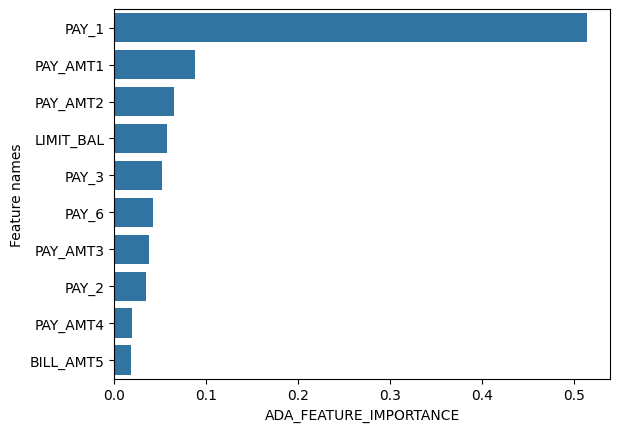

In [95]:
ada_top_features = feature_imp.sort_values(by="ADA_FEATURE_IMPORTANCE" ,ascending = False)

sns.barplot(data = ada_top10, y= "Feature names", x = "ADA_FEATURE_IMPORTANCE")

In [88]:
ada_classifier.feature_names_in_

array(['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
       'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'ID', 'SEX',
       'EDUCATION', 'MARRIAGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6'], dtype=object)

In [94]:
ada_top10 = ada_top_features.head(10)